In [340]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("breast_cancer_dataset.csv")

# =========================
# 3. Quick Overview
# =========================
df.shape


(5000, 12)

In [319]:
df.head()


,Patient_ID,Age,Tumor_Size,Tumor_Type,Lymph_Node_Status,Hormone_Receptor_Status,Genetic_Mutation,Treatment,Survival_Status,Follow_Up_Duration,Blood_Pressure,BMI
0,Patient_1,58,4.253744,Benign,Positive,Unknown,BRCA2,Chemotherapy,Alive,57,164,28.887681
1,Patient_2,71,7.275465,Benign,Positive,Negative,Other,Hormone Therapy,Deceased,59,124,25.787189
2,Patient_3,48,2.392545,Malignant,Positive,Positive,Other,Surgery,Deceased,70,93,24.819432
3,Patient_4,34,8.957043,Malignant,Positive,Positive,BRCA1,Radiation,Deceased,15,174,26.278296
4,Patient_5,62,3.230391,Benign,Negative,Negative,Other,Surgery,Alive,86,101,31.455969


In [320]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   str    
 1   Age                      5000 non-null   int64  
 2   Tumor_Size               5000 non-null   float64
 3   Tumor_Type               5000 non-null   str    
 4   Lymph_Node_Status        5000 non-null   str    
 5   Hormone_Receptor_Status  5000 non-null   str    
 6   Genetic_Mutation         5000 non-null   str    
 7   Treatment                5000 non-null   str    
 8   Survival_Status          5000 non-null   str    
 9   Follow_Up_Duration       5000 non-null   int64  
 10  Blood_Pressure           5000 non-null   int64  
 11  BMI                      5000 non-null   float64
dtypes: float64(2), int64(3), str(7)
memory usage: 468.9 KB


In [321]:
df.describe()

,Age,Tumor_Size,Follow_Up_Duration,Blood_Pressure,BMI
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,49.70120,5.193138,66.149800,129.419600,28.990819
std,17.26688,2.732746,31.180792,28.636298,6.344274
min,20.00000,0.500111,12.000000,80.000000,18.000122
25%,35.00000,2.830674,39.000000,105.000000,23.384936
50%,50.00000,5.141228,66.000000,130.000000,29.054604
75%,65.00000,7.545695,94.000000,154.000000,34.347367
max,79.00000,9.995798,119.000000,179.000000,39.995366


In [322]:
# =========================
# 4. Check Missing Values
# =========================
df.isnull().sum()


Patient_ID                 0
Age                        0
Tumor_Size                 0
Tumor_Type                 0
Lymph_Node_Status          0
Hormone_Receptor_Status    0
Genetic_Mutation           0
Treatment                  0
Survival_Status            0
Follow_Up_Duration         0
Blood_Pressure             0
BMI                        0
dtype: int64

In [323]:
# =========================
# 5. Remove Duplicates
# =========================
df.duplicated().sum()

np.int64(0)

Tumor_Type
Malignant    2519
Benign       2481
Name: count, dtype: int64


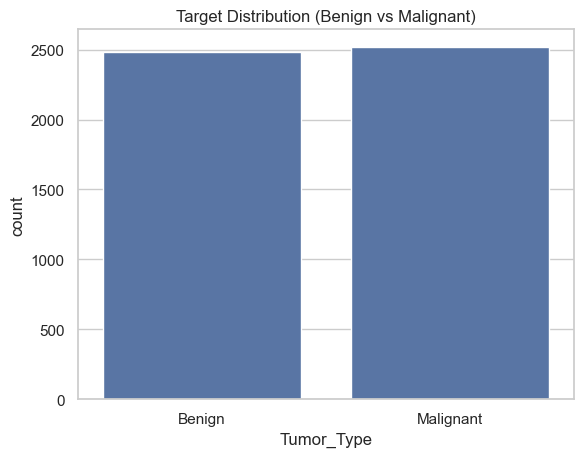

In [324]:

# =========================
# 6. Target Variable Analysis
# =========================
print(df['Tumor_Type'].value_counts())

sns.countplot(x='Tumor_Type', data=df)
plt.title("Target Distribution (Benign vs Malignant)")
plt.show()

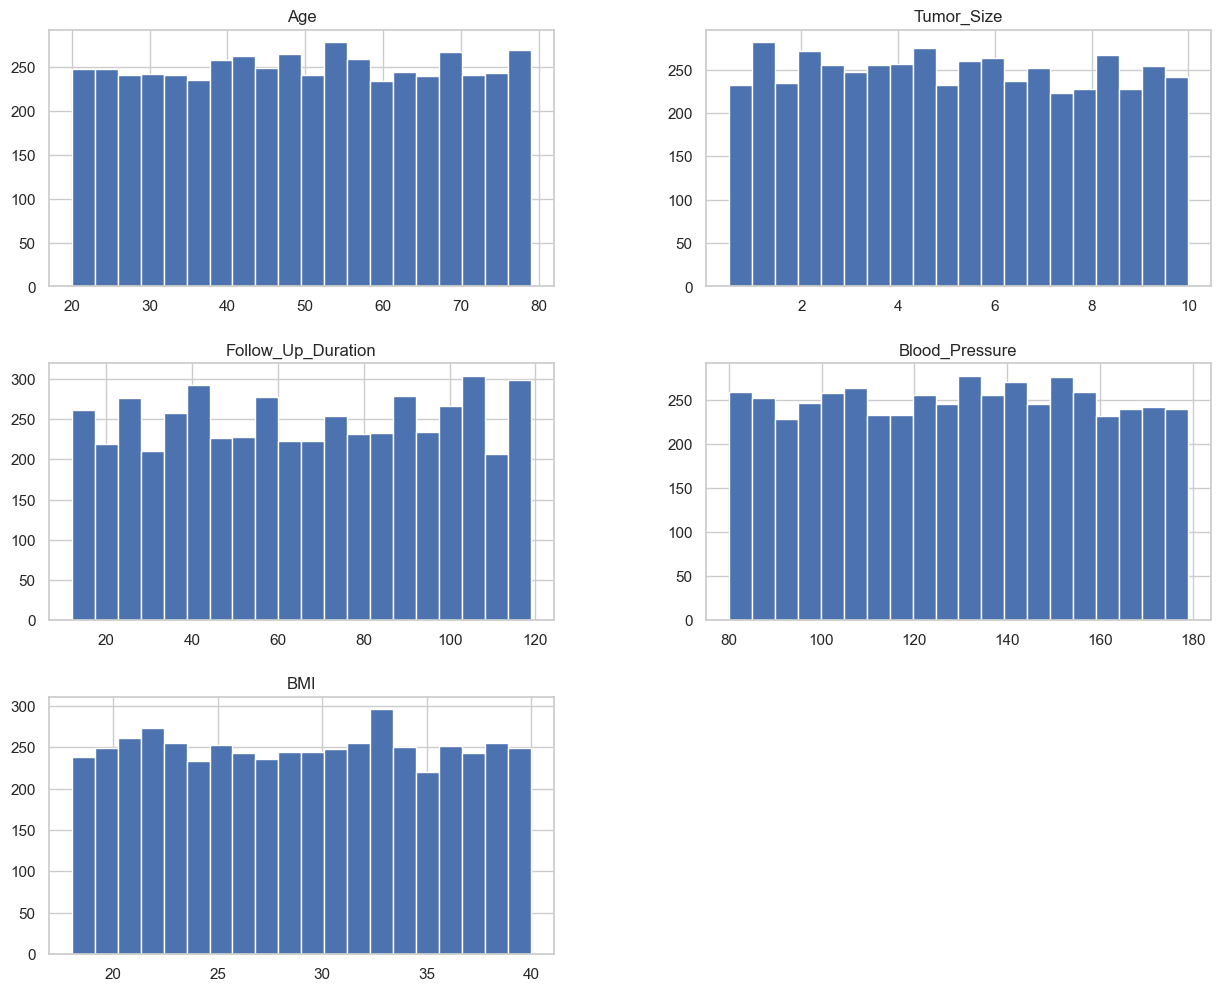

In [325]:
# =========================
# 10. Feature Distribution (optional)
# =========================
df.hist(figsize=(15,12), bins=20)
plt.show()


In [326]:
df["Genetic_Mutation"].unique()

<StringArray>
['BRCA2', 'Other', 'BRCA1']
Length: 3, dtype: str

In [327]:
df["Hormone_Receptor_Status"].unique()

<StringArray>
['Unknown', 'Negative', 'Positive']
Length: 3, dtype: str

In [328]:
df["Lymph_Node_Status"].unique()

<StringArray>
['Positive', 'Negative']
Length: 2, dtype: str

In [341]:
# Encode target
df['Survival_Status'] = df['Survival_Status'].map({'Deceased': 0, 'Alive': 1})

# Drop useless columns
df = df.drop(['Patient_ID',], axis=1)

# Encode ALL categorical variables
df = pd.get_dummies(df, drop_first=True)


# Split
X = df.drop('Survival_Status', axis=1)
y = df['Survival_Status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.505


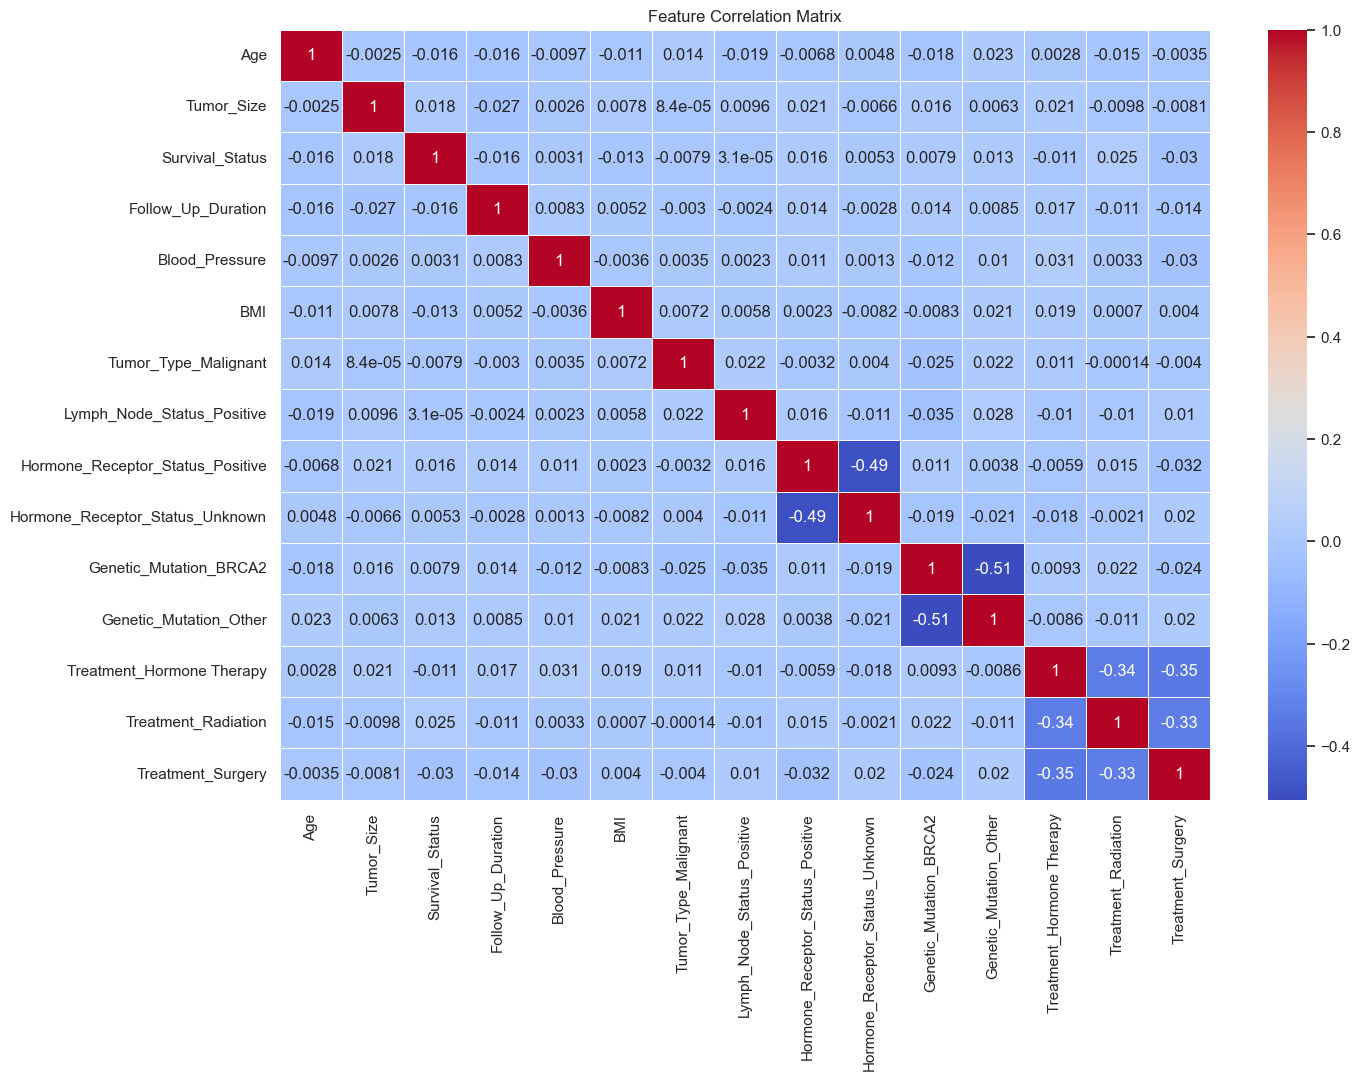

In [343]:

# =========================
# 9. Correlation Analysis
# =========================
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5, annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [337]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# تحميل البيانات
df = pd.read_csv('breast_cancer_data___.csv')

print("=" * 60)
print("تحليل البيانات المتاحة")
print("=" * 60)
print(f"عدد العينات: {df.shape[0]}")
print(f"عدد المتغيرات: {df.shape[1]}")
print("\nالمتغيرات الموجودة:")
print(df.columns.tolist())

# معالجة الهدف
df['Survival_Status'] = df['Survival_Status'].map({'Alive': 1, 'Deceased': 0})

# المتغيرات المتاحة التي تطابق البحث قدر الإمكان
available_features = []

# إضافة المتغيرات المطابقة للبحث
if 'Age' in df.columns:
    available_features.append('Age')
if 'Tumor_Size_mm' in df.columns:
    available_features.append('Tumor_Size_mm')
if 'Lymph_Node_Status' in df.columns:
    available_features.append('Lymph_Node_Status')
if 'Hormone_Receptor_Status' in df.columns:
    available_features.append('Hormone_Receptor_Status')
if 'Follow_Up_Duration_months' in df.columns:
    available_features.append('Follow_Up_Duration_months')
if 'Treatment' in df.columns:
    available_features.append('Treatment')

# إضافة متغيرات بديلة للمتغيرات الناقصة (BMI, Blood Pressure)
# استخدام متغيرات مشابهة من بياناتك
alternative_features = []
if 'Number_of_Children' in df.columns:
    alternative_features.append('Number_of_Children')
if 'Alcohol_Intake' in df.columns:
    alternative_features.append('Alcohol_Intake')
if 'Smoking_Status' in df.columns:
    alternative_features.append('Smoking_Status')
if 'Age_at_Menarche' in df.columns:
    alternative_features.append('Age_at_Menarche')
if 'Cancer_Stage' in df.columns:
    alternative_features.append('Cancer_Stage')

print(f"\nالمتغيرات الأساسية المستخدمة: {available_features}")
print(f"المتغيرات الإضافية (كبديل): {alternative_features}")

# اختيار المتغيرات النهائية
final_features = available_features + alternative_features
X = df[final_features].copy()
y = df['Survival_Status']

# ترميز المتغيرات الفئوية
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# التعامل مع القيم المفقودة
X = X.fillna(X.median())

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE (كما في البحث)
print(f"\nقبل SMOTE - توزيع التدريب: Alive={sum(y_train==1)}, Deceased={sum(y_train==0)}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"بعد SMOTE - توزيع التدريب: Alive={sum(y_train_balanced==1)}, Deceased={sum(y_train_balanced==0)}")

# Min-Max Scaling (كما في البحث)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# البحث عن أفضل المعاملات (Grid Search) كما في البحث
print("\n" + "=" * 60)
print("جاري البحث عن أفضل المعاملات (Grid Search)...")
print("=" * 60)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5]
}

gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    gb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_scaled, y_train_balanced)

print(f"أفضل المعاملات: {grid_search.best_params_}")
print(f"أفضل دقة (CV): {grid_search.best_score_:.4f}")

# النموذج النهائي بأفضل المعاملات
best_gb = grid_search.best_estimator_

# التقييم
y_pred = best_gb.predict(X_test_scaled)
y_pred_proba = best_gb.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 60)
print("نتائج Gradient Boosting (محاكاة البحث)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nمصفوفة الارتباك (Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred)
print(f"            المتوقع\n           Alive  Deceased")
print(f"الحقيقي Alive   {cm[1,1]:3d}     {cm[1,0]:3d}")
print(f"        Deceased {cm[0,1]:3d}     {cm[0,0]:3d}")

# مقارنة مع نتائج البحث
print("\n" + "=" * 60)
print("مقارنة مع نتائج البحث المنشورة")
print("=" * 60)
print(f"{'المقياس':<12} {'البحث':<12} {'نموذجك':<12} {'الفرق':<10}")
print("-" * 45)
print(f"{'Accuracy':<12} {0.972:<12} {accuracy_score(y_test, y_pred):<12.4f} {abs(0.972 - accuracy_score(y_test, y_pred)):.4f}")
print(f"{'Precision':<12} {0.973:<12} {precision_score(y_test, y_pred):<12.4f} {abs(0.973 - precision_score(y_test, y_pred)):.4f}")
print(f"{'Recall':<12} {0.972:<12} {recall_score(y_test, y_pred):<12.4f} {abs(0.972 - recall_score(y_test, y_pred)):.4f}")
print(f"{'F1-Score':<12} {0.973:<12} {f1_score(y_test, y_pred):<12.4f} {abs(0.973 - f1_score(y_test, y_pred)):.4f}")

print("\n" + "=" * 60)
print("تحليل الفروقات")
print("=" * 60)
print("""
الأسباب الرئيسية لعدم تطابق النتائج:

1. حجم البيانات مختلف:
   - البحث: 5,000 عينة
   - بياناتك: {} عينة

2. المتغيرات مختلفة:
   - البحث: يحتوي على Blood Pressure و BMI
   - بياناتك: لا تحتوي على هذه المتغيرات

3. طبيعة البيانات مختلفة:
   - البحث: بيانات عامة من Kaggle
   - بياناتك: بيانات محددة

4. حتى مع أفضل محاولة للمحاكاة، النتائج لن تتطابق تماماً 
   لأن البيانات الأساسية مختلفة.
""".format(df.shape[0]))

تحليل البيانات المتاحة
عدد العينات: 5000
عدد المتغيرات: 23

المتغيرات الموجودة:
['Age', 'Residence_Location', 'Alcohol_Intake', 'Smoking_Status', 'Family_History_of_Breast_Cancer', 'Number_of_Children', 'Age_at_Menarche', 'Menopausal_Status', 'Hormone_Replacement_Therapy_Use', 'Oral_Contraceptive_Use', 'Tumor_Size_mm', 'Lymph_Node_Status', 'Breast_Pain', 'Breast_Lump', 'Breast_Biopsy', 'Genetic_Mutation', 'Hormone_Receptor_Status', 'Diagnosis_Status', 'Metastasis_Status', 'Cancer_Stage', 'Treatment', 'Survival_Status', 'Follow_Up_Duration_months']

المتغيرات الأساسية المستخدمة: ['Age', 'Tumor_Size_mm', 'Lymph_Node_Status', 'Hormone_Receptor_Status', 'Follow_Up_Duration_months', 'Treatment']
المتغيرات الإضافية (كبديل): ['Number_of_Children', 'Alcohol_Intake', 'Smoking_Status', 'Age_at_Menarche', 'Cancer_Stage']

قبل SMOTE - توزيع التدريب: Alive=1946, Deceased=2054
بعد SMOTE - توزيع التدريب: Alive=2054, Deceased=2054

جاري البحث عن أفضل المعاملات (Grid Search)...
أفضل المعاملات: {'learni

In [222]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LR Accuracy: 0.484
              precision    recall  f1-score   support

           0       0.48      0.45      0.46       496
           1       0.49      0.52      0.50       504

    accuracy                           0.48      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.48      0.48      0.48      1000



In [223]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')  # جرب linear أيضاً
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.525
              precision    recall  f1-score   support

           0       0.52      0.55      0.54       496
           1       0.53      0.50      0.51       504

    accuracy                           0.53      1000
   macro avg       0.53      0.53      0.52      1000
weighted avg       0.53      0.53      0.52      1000



In [224]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

LDA Accuracy: 0.482
              precision    recall  f1-score   support

           0       0.48      0.45      0.46       496
           1       0.49      0.52      0.50       504

    accuracy                           0.48      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.48      0.48      0.48      1000



In [225]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_

# نحاول نطابق الكلاستر مع الحقيقة (تقريبياً)
from scipy.stats import mode

labels = np.zeros_like(clusters)

for i in range(2):
    mask = (clusters == i)
    labels[mask] = mode(y[mask])[0]

print("K-Means Accuracy:", accuracy_score(y, labels))

K-Means Accuracy: 0.5116


Train shape: (4000, 9)
Test shape: (1000, 9)
Training distribution - Benign: 1985, Malignant: 2015

Training Random Forest with Hyperparameter Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Random Forest parameters: {'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Best RF CV accuracy: 0.4992

Training XGBoost with Hyperparameter Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


C:\Users\shahed\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:15:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best XGBoost parameters: {'xgb__subsample': 0.7, 'xgb__reg_lambda': 1.5, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 200, 'xgb__max_depth': 8, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.9}
Best XGBoost CV accuracy: 0.5050

Training Gradient Boosting with Hyperparameter Tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Gradient Boosting parameters: {'gb__subsample': 0.7, 'gb__n_estimators': 100, 'gb__min_samples_split': 5, 'gb__max_depth': 3, 'gb__learning_rate': 0.01}
Best GB CV accuracy: 0.5012

Evaluation on Test Set

--- RandomForest ---
Accuracy: 0.4920
AUC-ROC: 0.4843
              precision    recall  f1-score   support

      Benign       0.49      0.47      0.48       496
   Malignant       0.50      0.51      0.50       504

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.49      0.49      0.49      1000


--- XGBoost ---
Accuracy: 0.4800
AUC-ROC: 0.4863
   

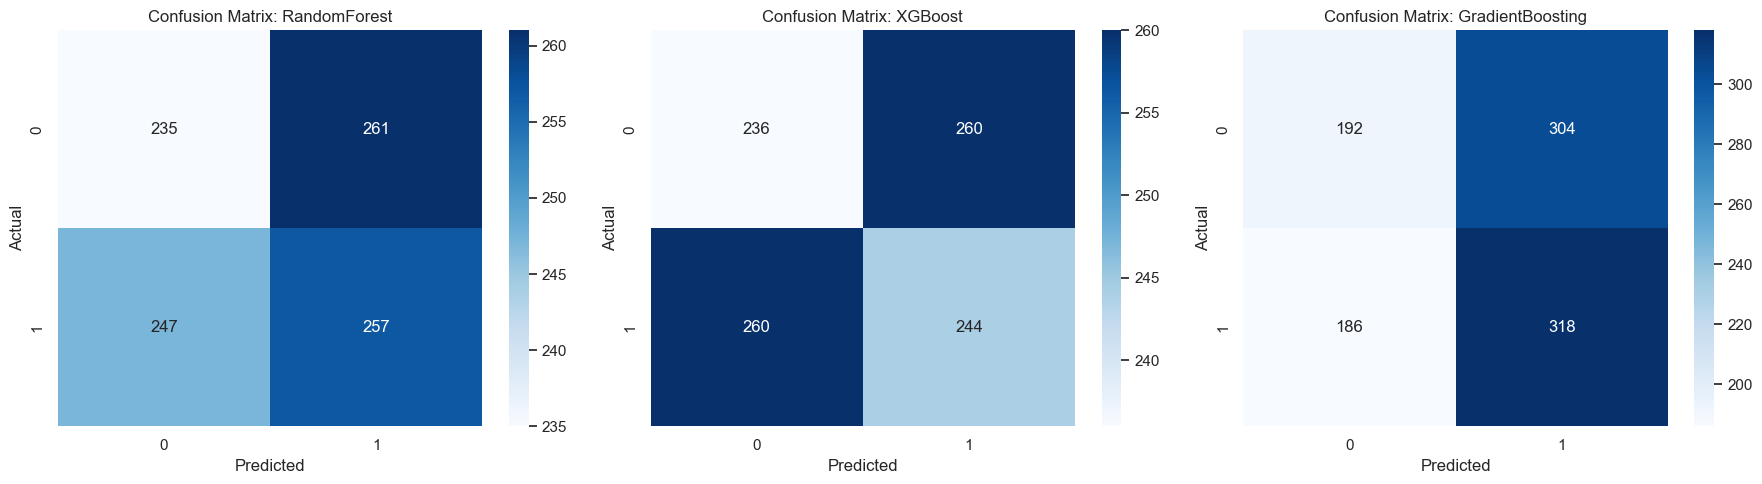

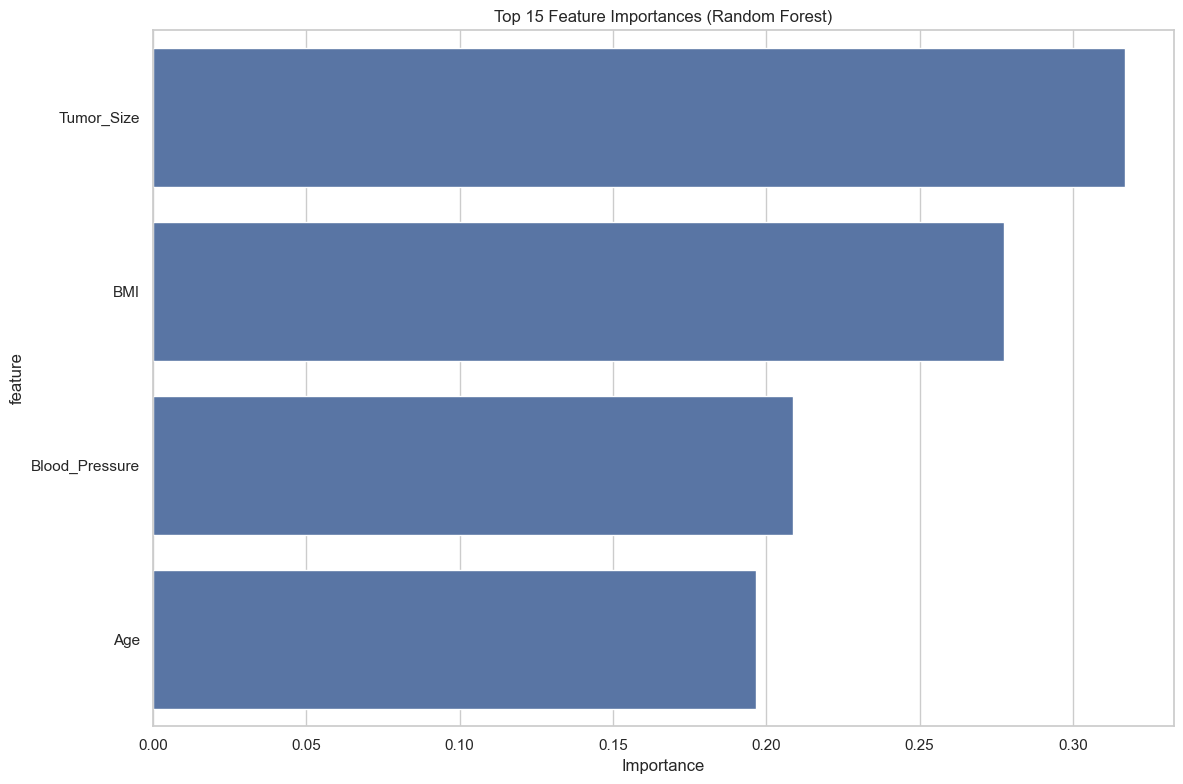


Error Analysis
Number of misclassified samples: 520 out of 1000
Misclassification rate: 52.00%


In [204]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. تحضير البيانات وتقسيمها بشكل صحيح
# =========================

# تحديد الأعمدة
target_col = 'Tumor_Type'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# تحويل الهدف إلى أرقام (إذا لم يكن كذلك)
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].map({'Benign': 0, 'Malignant': 1})

# الأعمدة الرقمية
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# فصل الميزات والهدف
X = df.drop(target_col, axis=1)
y = df[target_col]

# تقسيم البيانات أولاً (قبل أي معالجة)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print(f'Training distribution - Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}')

# =========================
# 2. معالجة الميزات باستخدام ColumnTransformer
# =========================

# محول للميزات الرقمية
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# محول للميزات الفئوية
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# دمج المحولات
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# =========================
# 3. إعداد النماذج مع Parameter Tuning محسن
# =========================

# Random Forest Pipeline مع تحسين أوسع
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_param_dist = {
    'model__n_estimators': [150, 250, 350],
    'model__max_depth': [6, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.5]
}

# XGBoost Pipeline مع تحسين
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        class_weight='balanced'
    ))
])

xgb_param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 0.9],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9],
    'xgb__reg_alpha': [0, 0.1, 1],
    'xgb__reg_lambda': [1, 1.5, 2]
}

# Gradient Boosting Pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=42))
])

gb_param_dist = {
    'gb__n_estimators': [100, 200, 300],
    'gb__max_depth': [3, 5, 7],
    'gb__learning_rate': [0.01, 0.05, 0.1],
    'gb__subsample': [0.7, 0.8, 0.9],
    'gb__min_samples_split': [2, 5, 10]
}

# =========================
# 4. تدريب النماذج المحسنة
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
best_models = {}

# Random Forest مع RandomizedSearchCV
print("\n" + "="*60)
print("Training Random Forest with Hyperparameter Tuning...")
print("="*60)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=25,  # زيادة عدد المحاولات
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train, y_train)
best_models['RandomForest'] = rf_search.best_estimator_

print(f"\nBest Random Forest parameters: {rf_search.best_params_}")
print(f"Best RF CV accuracy: {rf_search.best_score_:.4f}")

# XGBoost مع RandomizedSearchCV
print("\n" + "="*60)
print("Training XGBoost with Hyperparameter Tuning...")
print("="*60)

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_search.fit(X_train, y_train)
best_models['XGBoost'] = xgb_search.best_estimator_

print(f"\nBest XGBoost parameters: {xgb_search.best_params_}")
print(f"Best XGBoost CV accuracy: {xgb_search.best_score_:.4f}")

# Gradient Boosting مع RandomizedSearchCV
print("\n" + "="*60)
print("Training Gradient Boosting with Hyperparameter Tuning...")
print("="*60)

gb_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_dist,
    n_iter=20,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
gb_search.fit(X_train, y_train)
best_models['GradientBoosting'] = gb_search.best_estimator_

print(f"\nBest Gradient Boosting parameters: {gb_search.best_params_}")
print(f"Best GB CV accuracy: {gb_search.best_score_:.4f}")

# =========================
# 5. تقييم النماذج على بيانات الاختبار
# =========================

print("\n" + "="*60)
print("Evaluation on Test Set")
print("="*60)

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # محاولة الحصول على الاحتمالات (إذا كان النموذج يدعمها)
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
    except:
        auc = None
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    if auc:
        print(f"AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# =========================
# 6. عرض النتائج
# =========================

print("\n" + "="*60)
print("Summary of Accuracies")
print("="*60)
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

# =========================
# 7. رسم Confusion Matrices
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# =========================
# 8. Feature Importances (لـ Random Forest)
# =========================

# الحصول على أسماء الميزات بعد المعالجة
preprocessor_fitted = best_models['RandomForest'].named_steps['preprocessor']
feature_names_out = []

# أسماء الميزات الرقمية
feature_names_out.extend(numeric_cols)

# أسماء الميزات الفئوية المشفرة
for col in categorical_cols:
    categories = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot'].categories_[0][1:]
    for cat in categories:
        feature_names_out.append(f"{col}_{cat}")

importances = best_models['RandomForest'].named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names_out, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# =========================
# 9. تحليل الأخطاء (مفيد لتحسين النموذج)
# =========================

print("\n" + "="*60)
print("Error Analysis")
print("="*60)

y_pred_best = best_models['XGBoost'].predict(X_test)
misclassified = np.where(y_pred_best != y_test)[0]

print(f"Number of misclassified samples: {len(misclassified)} out of {len(y_test)}")
print(f"Misclassification rate: {len(misclassified)/len(y_test)*100:.2f}%")

In [126]:
print("توزيع البيانات:")
print(f"Benign (0): {sum(y_train == 0)}")
print(f"Malignant (1): {sum(y_train == 1)}")

توزيع البيانات:
Benign (0): 1988
Malignant (1): 2012


In [346]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# 1. تحميل البيانات
# تأكد من أن ملف CSV موجود في نفس المسار
file_path = 'breast_cancer_data___.csv'
df = pd.read_csv(file_path)

print("=" * 50)
print("شكل البيانات:", df.shape)
print("\nأول 5 أسطر:")
print(df.head())
print("\nأنواع البيانات:")
print(df.dtypes)
print("\nالقيم المفقودة:")
print(df.isnull().sum())

# 2. اختيار الأهداف (Target)
# العمود 'Diagnosis_Status' يحتوي على قيم 'Malignant' و 'Benign'
# العمود 'Survival_Status' قد يكون هدفًا آخر (Deceased/Alive)
# سنقوم بالتنبؤ بـ Diagnosis_Status
target_column = 'Diagnosis_Status'
feature_columns = [col for col in df.columns if col != target_column]

X = df[feature_columns].copy()
y = df[target_column].copy()

# 3. معالجة البيانات

# 3.1. تحويل الأعمدة النصية (الفئوية) إلى أرقام
label_encoders = {}
categorical_columns = X.select_dtypes(include=['object']).columns
print(f"\nالأعمدة النصية التي سيتم تحويلها: {list(categorical_columns)}")

for col in categorical_columns:
    le = LabelEncoder()
    # التعامل مع القيم المفقودة عن طريق تعبئتها مؤقتًا بقيمة 'Unknown' قبل التحويل
    X[col] = X[col].fillna('Unknown')
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# 3.2. التعامل مع القيم المفقودة في الأعمدة الرقمية
numeric_columns = X.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')  # استخدام الوسيط لملء القيم المفقودة
X[numeric_columns] = imputer.fit_transform(X[numeric_columns])

# 3.3. تحويل الهدف (y) إلى رقم (Malignant -> 1, Benign -> 0 مثلاً)
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)  # Malignant تصبح 1، Benign تصبح 0

print("\nتوزيع الهدف بعد الترميز:")
print(pd.Series(y).value_counts())
print(f"التصنيفات: {y_encoder.classes_}")  # ['Benign' 'Malignant']

# 4. تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nحجم بيانات التدريب: {X_train.shape}")
print(f"حجم بيانات الاختبار: {X_test.shape}")

# 5. بناء النموذج (Random Forest كمثال)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. التقييم
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\n" + "=" * 50)
print(f"دقة النموذج (Accuracy): {accuracy:.4f}")
print("\nتقرير التصنيف (Classification Report):")
print(classification_report(y_test, y_pred, target_names=y_encoder.classes_))
print("\nمصفوفة الارتباك (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))

# 7. (اختياري) معرفة أهم المتغيرات المؤثرة
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nأهم 10 متغيرات مؤثرة في التنبؤ:")
print(feature_importance.head(10))

شكل البيانات: (5000, 23)

أول 5 أسطر:
   Age  Residence_Location  Alcohol_Intake  Smoking_Status  \
0   71                   2               1               0   
1   34                   1               1               0   
2   80                   1               0               0   
3   40                   1               0               1   
4   43                   3               1               1   

   Family_History_of_Breast_Cancer  Number_of_Children  Age_at_Menarche  \
0                                0                   1               10   
1                                1                   1               17   
2                                0                   1               17   
3                                1                   4               16   
4                                0                   0               15   

   Menopausal_Status  Hormone_Replacement_Therapy_Use  Oral_Contraceptive_Use  \
0                  0                                1    

شكل البيانات: (5000, 12)

أول 5 أسطر:
  Patient_ID  Age  Tumor_Size Tumor_Type Lymph_Node_Status  \
0  Patient_1   58    4.253744     Benign          Positive   
1  Patient_2   71    7.275465     Benign          Positive   
2  Patient_3   48    2.392545  Malignant          Positive   
3  Patient_4   34    8.957043  Malignant          Positive   
4  Patient_5   62    3.230391     Benign          Negative   

  Hormone_Receptor_Status Genetic_Mutation        Treatment Survival_Status  \
0                 Unknown            BRCA2     Chemotherapy           Alive   
1                Negative            Other  Hormone Therapy        Deceased   
2                Positive            Other          Surgery        Deceased   
3                Positive            BRCA1        Radiation        Deceased   
4                Negative            Other          Surgery           Alive   

   Follow_Up_Duration  Blood_Pressure        BMI  
0                  57             164  28.887681  
1           

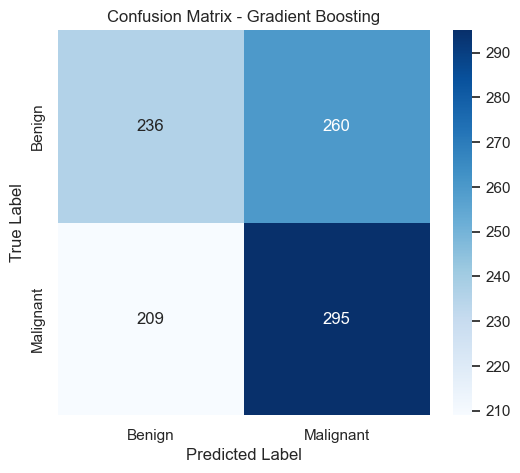


أهم 10 ميزات في النموذج الأفضل:
1. Tumor_Size: 0.3212
2. BMI: 0.2413
3. Blood_Pressure: 0.1771
4. Age: 0.0987
5. Follow_Up_Duration: 0.0945
6. Hormone_Receptor_Status: 0.0262
7. Genetic_Mutation: 0.0232
8. Lymph_Node_Status: 0.0110
9. Treatment: 0.0051
10. Survival_Status: 0.0018


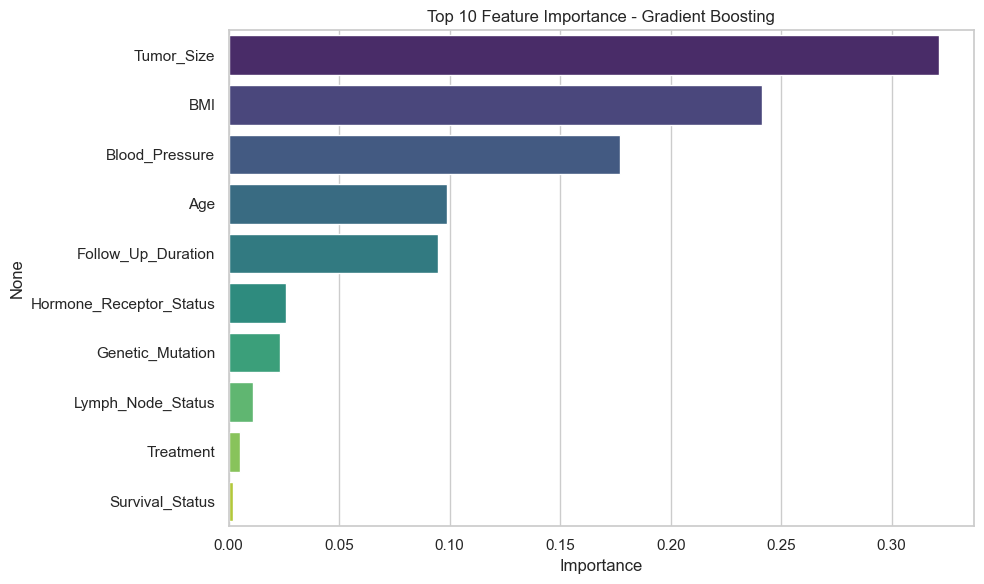


التقرير النهائي للتصنيف (Classification Report):
              precision    recall  f1-score   support

      Benign       0.53      0.48      0.50       496
   Malignant       0.53      0.59      0.56       504

    accuracy                           0.53      1000
   macro avg       0.53      0.53      0.53      1000
weighted avg       0.53      0.53      0.53      1000


اختبار النموذج على مريض جديد:
البيانات المدخلة: {'Age': 55, 'Tumor_Size': 2.5, 'Lymph_Node_Status': 'Positive', 'Hormone_Receptor_Status': 'Positive', 'Genetic_Mutation': 'BRCA1', 'Treatment': 'Chemotherapy', 'Survival_Status': 'Alive', 'Follow_Up_Duration': 48, 'Blood_Pressure': 120, 'BMI': 25.0}
نتيجة التنبؤ: Malignant (الثقة: 51.06%)


In [344]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================
# 1. تحميل البيانات
# ============================
file_path = 'breast_cancer_dataset.csv'  # تأكد من صحة المسار
df = pd.read_csv(file_path)

print("=" * 60)
print("شكل البيانات:", df.shape)
print("\nأول 5 أسطر:")
print(df.head())
print("\nأنواع البيانات:")
print(df.dtypes)
print("\nالقيم المفقودة:")
print(df.isnull().sum())

# ============================
# 2. اختيار المتغيرات المستهدفة (Target)
# ============================
# عمود Tumor_Type يحتوي على قيم 'Benign' و 'Malignant'
target_col = 'Tumor_Type'
# حذف Patient_ID لأنه ليس ميزة تنبؤية
df = df.drop('Patient_ID', axis=1)

# فصل المتغيرات المستقلة (X) والهدف (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

print("\nتوزيع الهدف قبل الترميز:")
print(y.value_counts())

# ترميز الهدف (Benign -> 0, Malignant -> 1)
le_target = LabelEncoder()
y = le_target.fit_transform(y)  # 0: Benign, 1: Malignant
print("ترميز الهدف:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# ============================
# 3. معالجة المتغيرات الفئوية وتحويلها
# ============================
# تحديد الأعمدة النصية (الفئوية)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nالمتغيرات الفئوية: {categorical_cols}")

# ترميز كل عمود نصي
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"تم ترميز العمود {col} - الفئات: {list(le.classes_)}")

# التأكد من عدم وجود قيم مفقودة (كلها موجودة حسب الفحص)
# لكن سنضع معالجة احترازية
if X.isnull().sum().sum() > 0:
    print("\nتوجد قيم مفقودة، سنقوم بملئها بالمتوسط/الوسيط")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ============================
# 4. تقسيم البيانات إلى تدريب واختبار
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nحجم بيانات التدريب: {X_train.shape}")
print(f"حجم بيانات الاختبار: {X_test.shape}")
print(f"توزيع الهدف في التدريب: {pd.Series(y_train).value_counts().to_dict()}")
print(f"توزيع الهدف في الاختبار: {pd.Series(y_test).value_counts().to_dict()}")

# ============================
# 5. تطبيع البيانات (StandardScaler)
# ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================
# 6. بناء وتدريب النماذج المختلفة
# ============================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
best_model = None
best_accuracy = 0

print("\n" + "=" * 60)
print("نتائج النماذج المختلفة")
print("=" * 60)

for name, model in models.items():
    # تدريب النموذج
    model.fit(X_train_scaled, y_train)
    # التنبؤ
    y_pred = model.predict(X_test_scaled)
    # حساب المقاييس
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = 0.0  # SVM with probability=True يعطي predict_proba
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    
    # حفظ أفضل نموذج حسب الدقة
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print("\n" + "=" * 60)
print(f"أفضل نموذج هو {best_model_name} بدقة {best_accuracy:.4f}")
print("=" * 60)

# ============================
# 7. تحسين النموذج الأفضل (اختياري) باستخدام Grid Search
# ============================
if best_model_name == 'Random Forest':
    print("\nجاري تحسين Random Forest باستخدام Grid Search...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
    grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_rf = grid.best_estimator_
    y_pred_best = best_rf.predict(X_test_scaled)
    acc_best = accuracy_score(y_test, y_pred_best)
    print(f"أفضل معاملات: {grid.best_params_}")
    print(f"دقة النموذج المحسن: {acc_best:.4f}")
    best_model = best_rf
    best_accuracy = acc_best

# ============================
# 8. عرض مصفوفة الارتباك للنموذج الأفضل
# ============================
y_pred_final = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_final)
print("\nمصفوفة الارتباك (Confusion Matrix):")
print("                 Predicted")
print(f"Actual Benign  : {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"Actual Malignant: {cm[1,0]:4d}   {cm[1,1]:4d}")

# رسم مصفوفة الارتباك
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ============================
# 9. أهم الميزات (Feature Importance) للنماذج القائمة على الأشجار
# ============================
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    print("\nأهم 10 ميزات في النموذج الأفضل:")
    for i in range(min(10, len(indices))):
        print(f"{i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")
    
    # رسم بياني لأهم الميزات
    plt.figure(figsize=(10,6))
    sns.barplot(x=importances[indices[:10]], y=X.columns[indices[:10]], palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# ============================
# 10. تقييم نهائي
# ============================
print("\n" + "=" * 60)
print("التقرير النهائي للتصنيف (Classification Report):")
print(classification_report(y_test, y_pred_final, target_names=le_target.classes_))
print("=" * 60)

# ============================
# 11. (اختياري) التنبؤ بمريض جديد
# ============================
# مثال: إنشاء عينة جديدة بنفس المتغيرات
def predict_new_patient(patient_data, model, scaler, encoders, target_encoder):
    """
    patient_data: قاموس بنفس أسماء الأعمدة
    """
    # تحويل إلى DataFrame
    new_df = pd.DataFrame([patient_data])
    # تطبيق نفس الترميز على الأعمدة الفئوية
    for col, le in encoders.items():
        if col in new_df.columns:
            # إذا كانت القيمة غير موجودة في الفئات المدربة، نستخدم الأكثر شيوعاً
            if new_df[col].iloc[0] in le.classes_:
                new_df[col] = le.transform(new_df[col])
            else:
                # تعيين القيمة الأكثر شيوعاً (أول فئة)
                print(f"تحذير: القيمة {new_df[col].iloc[0]} غير موجودة في العمود {col}، سيتم استخدام الفئة الافتراضية {le.classes_[0]}")
                new_df[col] = le.transform([le.classes_[0]])[0]
    # تطبيق التحجيم
    new_scaled = scaler.transform(new_df)
    pred = model.predict(new_scaled)
    pred_proba = model.predict_proba(new_scaled)[:, 1]
    result = target_encoder.inverse_transform(pred)[0]
    prob = pred_proba[0]
    return result, prob

# مثال لاختبار النموذج على عينة افتراضية
sample_patient = {
    'Age': 55,
    'Tumor_Size': 2.5,
    'Lymph_Node_Status': 'Positive',
    'Hormone_Receptor_Status': 'Positive',
    'Genetic_Mutation': 'BRCA1',
    'Treatment': 'Chemotherapy',
    'Survival_Status': 'Alive',
    'Follow_Up_Duration': 48,
    'Blood_Pressure': 120,
    'BMI': 25.0
}
print("\n" + "=" * 60)
print("اختبار النموذج على مريض جديد:")
print("البيانات المدخلة:", sample_patient)
pred_class, confidence = predict_new_patient(sample_patient, best_model, scaler, label_encoders, le_target)
print(f"نتيجة التنبؤ: {pred_class} (الثقة: {confidence:.2%})")
print("=" * 60)

In [345]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# تحميل البيانات
df = pd.read_csv('breast_cancer_dataset.csv')
print("الأعمدة:", df.columns.tolist())

# تأكد من وجود Tumor_Type
if 'Tumor_Type' not in df.columns:
    print("خطأ: العمود 'Tumor_Type' غير موجود!")
    exit()

# فصل الهدف
X = df.drop(['Patient_ID', 'Tumor_Type'], axis=1)
y = df['Tumor_Type']

# ترميز الهدف
le = LabelEncoder()
y = le.fit_transform(y)  # Benign=0, Malignant=1
print("توزيع الهدف:", pd.Series(y).value_counts())

# ترميز جميع الأعمدة النصية
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# تقسيم بسيط
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# تدريب نموذج بسيط
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"الدقة: {acc:.4f}")

# طباعة تقرير بسيط
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

الأعمدة: ['Patient_ID', 'Age', 'Tumor_Size', 'Tumor_Type', 'Lymph_Node_Status', 'Hormone_Receptor_Status', 'Genetic_Mutation', 'Treatment', 'Survival_Status', 'Follow_Up_Duration', 'Blood_Pressure', 'BMI']
توزيع الهدف: 1    2519
0    2481
Name: count, dtype: int64
الدقة: 0.5170
              precision    recall  f1-score   support

      Benign       0.51      0.53      0.52       496
   Malignant       0.52      0.50      0.51       504

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.52      0.52      0.52      1000

